# **Extracción**

#### En esta etapa se realizó la importación de los datos desde la API proporcionada por Telecom X.  
#### Los datos se encuentran en formato JSON y contienen información demográfica, servicios contratados y estado de evasión de los clientes.

In [15]:
import pandas as pd

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

df = pd.read_json(url)

df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


# **Transformación**

#### Debido a que el archivo JSON contiene estructuras anidadas, fue necesario normalizar las columnas para obtener un DataFrame plano.

####Posteriormente, se verificaron tipos de datos, valores nulos y posibles inconsistencias.

In [16]:
customer_df = pd.json_normalize(df['customer'])
phone_df = pd.json_normalize(df['phone'])
internet_df = pd.json_normalize(df['internet'])
account_df = pd.json_normalize(df['account'])

df = pd.concat(
    [df[['customerID', 'Churn']],
     customer_df,
     phone_df,
     internet_df,
     account_df],
    axis=1
)

df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [18]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

In [19]:
df['Cuentas_Diarias'] = df['Charges.Monthly'] / 30

#  Carga y análisis



#### Se realizó un análisis exploratorio de datos (EDA) con el objetivo de identificar patrones asociados a la evasión de clientes.

In [20]:
df[['tenure', 'Charges.Monthly', 'Charges.Total']].describe()

,tenure,Charges.Monthly
count,7267.000000,7267.000000
mean,32.346498,64.720098
std,24.571773,30.129572
min,0.000000,18.250000
25%,9.000000,35.425000
50%,29.000000,70.300000
75%,55.000000,89.875000
max,72.000000,118.750000


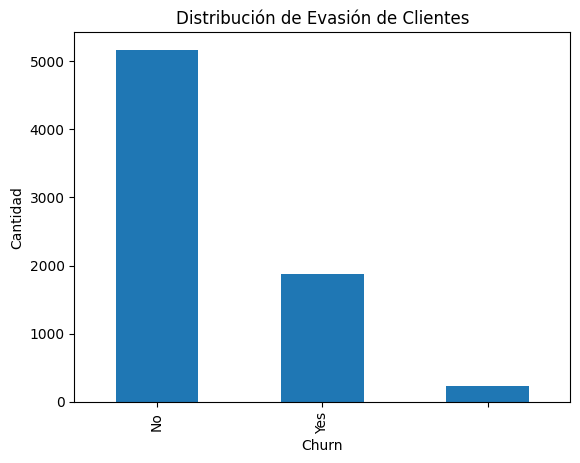

In [21]:
import matplotlib.pyplot as plt

df['Churn'].value_counts().plot(kind='bar')
plt.title("Distribución de Evasión de Clientes")
plt.xlabel("Churn")
plt.ylabel("Cantidad")
plt.show()

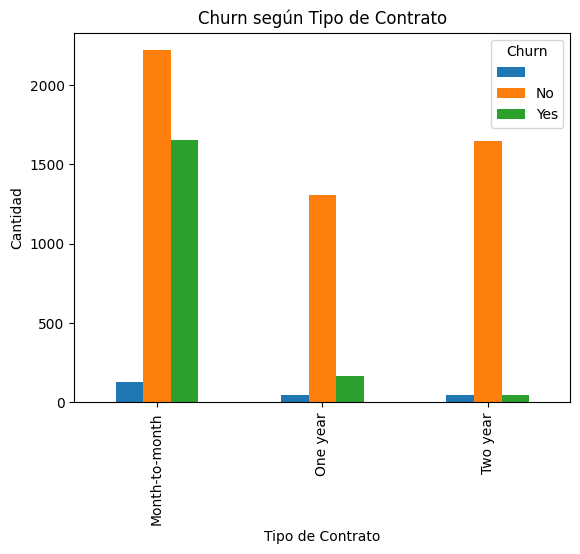

In [22]:
pd.crosstab(df['Contract'], df['Churn']).plot(kind='bar')
plt.title("Churn según Tipo de Contrato")
plt.xlabel("Tipo de Contrato")
plt.ylabel("Cantidad")
plt.show()

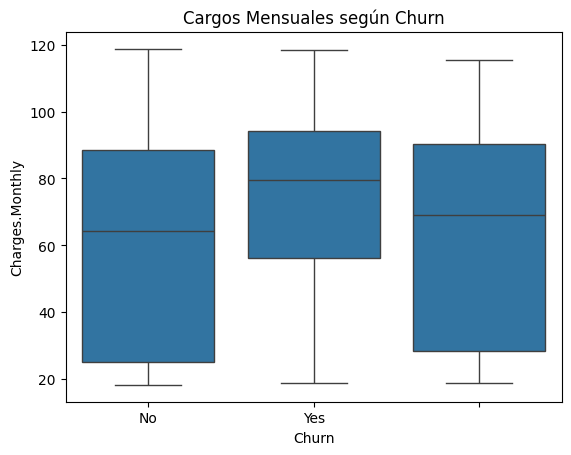

In [23]:
import seaborn as sns

sns.boxplot(x='Churn', y='Charges.Monthly', data=df)
plt.title("Cargos Mensuales según Churn")
plt.show()

#  Informe Final

##  Objetivo

Analizar los factores que influyen en la evasión de clientes (Churn) en Telecom X.

##  Limpieza y Preparación

Se normalizaron las columnas del JSON, se verificaron tipos de datos, valores nulos y se creó una variable adicional para enriquecer el análisis.

##  Principales Hallazgos

- Los contratos mensuales presentan mayor tasa de evasión.
- Los clientes con mayores cargos mensuales tienden a cancelar con más frecuencia.
- Un menor tiempo de permanencia (tenure) está asociado a mayor churn.

##  Recomendaciones

- Incentivar contratos de largo plazo.
- Implementar estrategias de fidelización en los primeros meses.
- Analizar planes para clientes con altos cargos mensuales.